In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [4]:
iris=load_iris()
X=iris.data
df=pd.DataFrame(X,columns=iris.feature_names)

In [5]:
df.shape

(150, 4)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

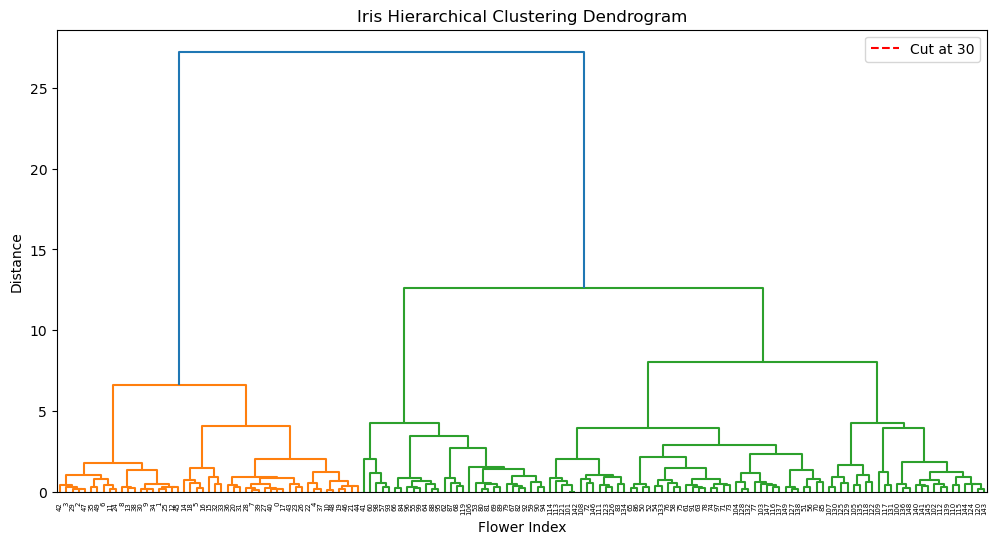

In [11]:
linkage_matrix=linkage(X_scaler,method='ward')

plt.figure(figsize=(12,6))
dendrogram(linkage_matrix)
plt.title('Iris Hierarchical Clustering Dendrogram')
plt.xlabel('Flower Index')
plt.ylabel('Distance')
plt.axhline(y=30,color='red',linestyle='--',label='Cut at 30')
plt.legend()
plt.show()

In [12]:
model=AgglomerativeClustering(n_clusters=3,linkage='ward')
clusters=model.fit_predict(X_scaler)

df['Cluster']=clusters
df['Cluster'].value_counts()

Cluster
0    71
1    49
2    30
Name: count, dtype: int64

In [13]:
# Which flowers are in which cluster?
print(df.groupby('Cluster').size())


Cluster
0    71
1    49
2    30
dtype: int64


In [14]:
# Compare with actual species
species=iris.target_names[iris.target]
df['Species'] = species
df.groupby('Cluster')['Species'].value_counts()

Cluster  Species   
0        virginica     48
         versicolor    23
1        setosa        49
2        versicolor    27
         virginica      2
         setosa         1
Name: count, dtype: int64